# EBM Variance Measurement

같은 데이터셋에서 randomness source만 바꿔 K=4개의 TabEBM을 학습하고,
같은 입력 x에 대한 `E_k(x)`의 member-간 분산/상관을 측정한다.

두 randomness source를 각각 측정:
- **A. distance**: 모든 데이터 사용, negative sample 거리 `[2, 5, 10, 15]`
- **B. subsample**: neg_distance=5 고정, 데이터 50% 랜덤 선택

각 method에 대해 같은 포맷의 표를 출력한다. 시각화/해석은 포함하지 않는다.

In [40]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/home/work/JooKyung/TabEBM')

import warnings
warnings.filterwarnings('ignore')

import subprocess
import json
import numpy as np
import pandas as pd
from pathlib import Path

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)
pd.set_option('display.precision', 4)

def run_cmd(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.stdout: print(result.stdout)
    if result.returncode != 0 and result.stderr: print('ERROR:', result.stderr[-500:])
    return result.returncode

REGION_ORDER = ['real', 'near', 'far']

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 실험 설정

| 항목 | 값 |
|---|---|
| Dataset | `stock` (OpenML 841) |
| Target class | 0 |
| `n_real` | 100 |
| Class samples | 53 |
| Features | 9 |
| `K` (n_ebms) | 4 |
| Eval points | `real`(53) + `near`(200, class mean + N(0, 0.5²)) + `far`(200, class mean + N(0, 3²)) |
| Random points (별도) | 100 (feature-wise uniform within X_all range) |
| Method A | `distance`, neg_distances=`[2, 5, 10, 15]`, 모든 데이터 사용 |
| Method B | `subsample`, neg_distance=`5` 고정, 데이터 50% 랜덤 |

### 저장된 CSV 스키마
- `ensemble_stats.csv`: `eval_idx, region, energy_mean, energy_std, energy_range, gar, grad_var`
- `diversity_summary.csv`: region별로 위 4지표의 `{mean, median, count}` 집계
- `pairwise_correlation.csv`: K개 EBM 모든 쌍의 Pearson r (6 pairs for K=4)
- `variance_real_vs_random.csv`: real 데이터와 random 포인트의 energy variance 요약
- `ebm_comparison_per_point.csv`: 각 포인트의 feature + K개 EBM energy + mean/var
- `energy_per_ebm.csv`: (ebm_idx, eval_idx, region, energy) long-form

---
## A. Distance ensemble

### A.0 fit + compare

In [41]:
run_cmd(
    'python experiments/ensemble_ebm.py fit '
    '--dataset stock --target_class 0 --n_real 100 '
    '--method distance --n_ebms 4 --neg_distances 2 5 10 15 '
    '--save_dir experiments/ebms/stock_distance'
)


FIT: 4 EBMs for stock class=0
  Method: distance
  Distances: [2.0, 5.0, 10.0, 15.0]
  Class 0: 53 samples, 9 features
  Save to: experiments/ebms/stock_distance

  Saved EBM 0: distance=2.0, all 53 samples
  Saved EBM 1: distance=5.0, all 53 samples
  Saved EBM 2: distance=10.0, all 53 samples
  Saved EBM 3: distance=15.0, all 53 samples

  Done. 4 EBMs saved to experiments/ebms/stock_distance/



0

In [42]:
run_cmd(
    'python experiments/ensemble_ebm.py compare '
    '--ebm_dir experiments/ebms/stock_distance --gpu 0'
)


COMPARE: 4 EBMs from experiments/ebms/stock_distance
  Distances: [2.0, 5.0, 10.0, 15.0]

  EBM 0 (d=2.0): energy [-4.34, -2.31]
  EBM 1 (d=5.0): energy [-4.55, -2.35]
  EBM 2 (d=10.0): energy [-4.36, -2.46]
  EBM 3 (d=15.0): energy [-4.40, -2.49]

DIVERSITY SUMMARY (by region)
        energy_std_mean  energy_std_median  energy_std_count  energy_range_mean  energy_range_median  energy_range_count  gar_mean  gar_median  gar_count  grad_var_mean  grad_var_median  grad_var_count
region                                                                                                                                                                                                   
far              0.1519             0.1333               200             0.3612               0.3086                 200    0.5998      0.6119        200         0.0000           0.0000             200
near             0.2794             0.2724               200             0.6979               0.6729              

0

### A.1 Region별 집계 — `diversity_summary.csv`

In [43]:
dist_sum = pd.read_csv('experiments/ebms/stock_distance/compare/diversity_summary.csv')
dist_sum = dist_sum.set_index('region').loc[REGION_ORDER].reset_index()
print(dist_sum.to_string(index=False))

region  energy_std_mean  energy_std_median  energy_std_count  energy_range_mean  energy_range_median  energy_range_count  gar_mean  gar_median  gar_count  grad_var_mean  grad_var_median  grad_var_count
  real           0.1098             0.1099                53             0.3003               0.3086                  53    0.6387      0.6527         53         0.0001           0.0000              53
  near           0.2794             0.2724               200             0.6979               0.6729                 200    0.7260      0.7366        200         0.0002           0.0002             200
   far           0.1519             0.1333               200             0.3612               0.3086                 200    0.5998      0.6119        200         0.0000           0.0000             200


### A.2 Pairwise Pearson r — `pairwise_correlation.csv`

In [44]:
dist_corr = pd.read_csv('experiments/ebms/stock_distance/compare/pairwise_correlation.csv')
print(dist_corr.to_string(index=False))
print(f'\n평균 r = {dist_corr.pearson_r.mean():.4f}    '
      f'min r = {dist_corr.pearson_r.min():.4f}    '
      f'max r = {dist_corr.pearson_r.max():.4f}')

 ebm_i  dist_i  ebm_j  dist_j  pearson_r
     0     2.0      1     5.0     0.9586
     0     2.0      2    10.0     0.9114
     0     2.0      3    15.0     0.9272
     1     5.0      2    10.0     0.9720
     1     5.0      3    15.0     0.9766
     2    10.0      3    15.0     0.9934

평균 r = 0.9565    min r = 0.9114    max r = 0.9934


### A.3 Real vs Random variance — `variance_real_vs_random.csv`

In [45]:
dist_var = pd.read_csv('experiments/ebms/stock_distance/compare/variance_real_vs_random.csv')
print(dist_var.to_string(index=False))

        group  n_points  variance_mean  variance_median  variance_max  variance_min
    real_data        53         0.0128           0.0121        0.0342        0.0045
random_points       100         0.1723           0.1595        0.3989        0.0143


### A.4 `energy_std` top-10 / bottom-10 — `ensemble_stats.csv`

In [46]:
dist_stats = pd.read_csv('experiments/ebms/stock_distance/compare/ensemble_stats.csv')
print('top-10 by energy_std')
print(dist_stats.nlargest(10, 'energy_std').to_string(index=False))
print('\nbottom-10 by energy_std')
print(dist_stats.nsmallest(10, 'energy_std').to_string(index=False))

top-10 by energy_std
 eval_idx region  energy_mean  energy_std  energy_range    gar   grad_var
      163   near      -3.5356      0.5678        1.4453 0.7317 1.4400e-04
      237   near      -3.7090      0.5497        1.3809 0.7158 7.9000e-05
      177   near      -3.8335      0.5186        1.3184 0.6793 1.4500e-04
      123   near      -3.7852      0.5050        1.2754 0.8074 9.7000e-05
      219   near      -3.2959      0.4881        1.2891 0.8525 4.3000e-05
      153   near      -3.7876      0.4779        1.1504 0.8175 2.0500e-04
       82   near      -3.6611      0.4764        1.1895 0.7386 1.7500e-04
      239   near      -3.5278      0.4729        1.1250 0.7914 1.5700e-04
       76   near      -3.5229      0.4667        1.1543 0.8586 1.5800e-04
       86   near      -3.5762      0.4620        1.1758 0.8240 1.9100e-04

bottom-10 by energy_std
 eval_idx region  energy_mean  energy_std  energy_range    gar   grad_var
      132   near      -4.0215      0.0421        0.1055 0.6402 1.8

### A.5 Per-point raw energies — `ebm_comparison_per_point.csv`

각 포인트의 feature 9개 + K=4개 EBM energy + mean/var. 숫자 확인용.

In [47]:
dist_pts = pd.read_csv('experiments/ebms/stock_distance/compare/ebm_comparison_per_point.csv')
ebm_cols_d = [c for c in dist_pts.columns if c.startswith('ebm_')]

print('== real data (n=53) — head 15 ==')
cols_show = ['point_idx', 'type'] + ebm_cols_d + ['energy_mean', 'energy_var']
print(dist_pts[dist_pts['type']=='real'][cols_show].head(15).to_string(index=False))

print('\n== random points (n=100) — head 10 ==')
print(dist_pts[dist_pts['type']=='random'][cols_show].head(10).to_string(index=False))

print(f'\ntotal rows: real={(dist_pts.type=="real").sum()}  random={(dist_pts.type=="random").sum()}')

== real data (n=53) — head 15 ==
 point_idx type  ebm_0_d2.0  ebm_1_d5.0  ebm_2_d10.0  ebm_3_d15.0  energy_mean  energy_var
         0 real     -4.2148     -4.4609      -4.3242      -4.4023      -4.3506      0.0085
         1 real     -4.0586     -4.5078      -4.3203      -4.3633      -4.3125      0.0263
         2 real     -4.2305     -4.5469      -4.3438      -4.3906      -4.3779      0.0129
         3 real     -3.9590     -4.4609      -4.3086      -4.3203      -4.2622      0.0342
         4 real     -4.2109     -4.4609      -4.3086      -4.3984      -4.3447      0.0089
         5 real     -4.2539     -4.4883      -4.3398      -4.3867      -4.3672      0.0072
         6 real     -4.2305     -4.4375      -4.3359      -4.3867      -4.3477      0.0059
         7 real     -4.2812     -4.4961      -4.3242      -4.3711      -4.3682      0.0065
         8 real     -4.2734     -4.5000      -4.3281      -4.3594      -4.3652      0.0070
         9 real     -4.1953     -4.5000      -4.3125     

### A.6 Per-EBM long-form — `energy_per_ebm.csv` (head)

In [48]:
dist_epe = pd.read_csv('experiments/ebms/stock_distance/compare/energy_per_ebm.csv')
print(f'shape: {dist_epe.shape}  (= K=4 × eval_points=453)')
print('head 20')
print(dist_epe.head(20).to_string(index=False))

shape: (1812, 5)  (= K=4 × eval_points=453)
head 20
 ebm_idx  neg_distance  eval_idx region  energy
       0           2.0         0   real -4.2148
       0           2.0         1   real -4.0586
       0           2.0         2   real -4.2305
       0           2.0         3   real -3.9590
       0           2.0         4   real -4.2109
       0           2.0         5   real -4.2539
       0           2.0         6   real -4.2305
       0           2.0         7   real -4.2812
       0           2.0         8   real -4.2734
       0           2.0         9   real -4.1953
       0           2.0        10   real -4.2500
       0           2.0        11   real -4.1875
       0           2.0        12   real -4.1250
       0           2.0        13   real -4.2422
       0           2.0        14   real -4.1484
       0           2.0        15   real -4.0742
       0           2.0        16   real -4.1328
       0           2.0        17   real -4.1406
       0           2.0        18   r

---
## B. Subsample ensemble

### B.0 fit + compare

In [49]:
run_cmd(
    'python experiments/ensemble_ebm.py fit '
    '--dataset stock --target_class 0 --n_real 100 '
    '--method subsample --n_ebms 4 --subsample_ratio 0.5 --neg_distance 5.0 '
    '--save_dir experiments/ebms/stock_subsample'
)


FIT: 4 EBMs for stock class=0
  Method: subsample
  Subsample ratio: 0.5, neg_distance: 5.0
  Class 0: 53 samples, 9 features
  Save to: experiments/ebms/stock_subsample

  Saved EBM 0: subsample 26/53 samples, distance=5.0
  Saved EBM 1: subsample 26/53 samples, distance=5.0
  Saved EBM 2: subsample 26/53 samples, distance=5.0
  Saved EBM 3: subsample 26/53 samples, distance=5.0

  Done. 4 EBMs saved to experiments/ebms/stock_subsample/



0

In [50]:
run_cmd(
    'python experiments/ensemble_ebm.py compare '
    '--ebm_dir experiments/ebms/stock_subsample --gpu 0'
)


COMPARE: 4 EBMs from experiments/ebms/stock_subsample
  Distances: [5.0, 5.0, 5.0, 5.0]

  EBM 0 (d=5.0): energy [-4.23, -2.35]
  EBM 1 (d=5.0): energy [-4.37, -2.28]
  EBM 2 (d=5.0): energy [-4.23, -2.37]
  EBM 3 (d=5.0): energy [-4.29, -2.28]

DIVERSITY SUMMARY (by region)
        energy_std_mean  energy_std_median  energy_std_count  energy_range_mean  energy_range_median  energy_range_count  gar_mean  gar_median  gar_count  grad_var_mean  grad_var_median  grad_var_count
region                                                                                                                                                                                                   
far              0.0552             0.0494               200             0.1430               0.1289                 200    0.7359      0.7969        200         0.0000           0.0000             200
near             0.0942             0.0874               200             0.2433               0.2227                 

0

### B.1 Region별 집계

In [51]:
sub_sum = pd.read_csv('experiments/ebms/stock_subsample/compare/diversity_summary.csv')
sub_sum = sub_sum.set_index('region').loc[REGION_ORDER].reset_index()
print(sub_sum.to_string(index=False))

region  energy_std_mean  energy_std_median  energy_std_count  energy_range_mean  energy_range_median  energy_range_count  gar_mean  gar_median  gar_count  grad_var_mean  grad_var_median  grad_var_count
  real           0.1188             0.0958                53             0.2984               0.2656                  53    0.6934      0.7136         53         0.0001           0.0001              53
  near           0.0942             0.0874               200             0.2433               0.2227                 200    0.8152      0.8414        200         0.0001           0.0001             200
   far           0.0552             0.0494               200             0.1430               0.1289                 200    0.7359      0.7969        200         0.0000           0.0000             200


### B.2 Pairwise Pearson r

In [52]:
sub_corr = pd.read_csv('experiments/ebms/stock_subsample/compare/pairwise_correlation.csv')
print(sub_corr.to_string(index=False))
print(f'\n평균 r = {sub_corr.pearson_r.mean():.4f}    '
      f'min r = {sub_corr.pearson_r.min():.4f}    '
      f'max r = {sub_corr.pearson_r.max():.4f}')

 ebm_i  dist_i  ebm_j  dist_j  pearson_r
     0     5.0      1     5.0     0.9830
     0     5.0      2     5.0     0.9878
     0     5.0      3     5.0     0.9778
     1     5.0      2     5.0     0.9812
     1     5.0      3     5.0     0.9702
     2     5.0      3     5.0     0.9689

평균 r = 0.9781    min r = 0.9689    max r = 0.9878


### B.3 Real vs Random variance

In [53]:
sub_var = pd.read_csv('experiments/ebms/stock_subsample/compare/variance_real_vs_random.csv')
print(sub_var.to_string(index=False))

        group  n_points  variance_mean  variance_median  variance_max  variance_min
    real_data        53         0.0205           0.0092        0.1233        0.0005
random_points       100         0.0185           0.0160        0.0608        0.0022


### B.4 `energy_std` top-10 / bottom-10

In [54]:
sub_stats = pd.read_csv('experiments/ebms/stock_subsample/compare/ensemble_stats.csv')
print('top-10 by energy_std')
print(sub_stats.nlargest(10, 'energy_std').to_string(index=False))
print('\nbottom-10 by energy_std')
print(sub_stats.nsmallest(10, 'energy_std').to_string(index=False))

top-10 by energy_std
 eval_idx region  energy_mean  energy_std  energy_range    gar   grad_var
       14   real      -3.9390      0.3512        0.9043 0.5201 5.6100e-04
       17   real      -3.9214      0.3320        0.7988 0.5803 2.5000e-04
       22   real      -3.9194      0.3131        0.8633 0.8541 8.9000e-05
       24   real      -3.9648      0.3048        0.7461 0.4379 2.7900e-04
      154   near      -3.7124      0.2510        0.6543 0.9167 1.0300e-04
      225   near      -3.5693      0.2453        0.6309 0.7863 4.3000e-04
      104   near      -3.4424      0.2387        0.6016 0.8389 1.2100e-04
      147   near      -3.5127      0.2359        0.5840 0.8721 1.7700e-04
      152   near      -3.8838      0.2310        0.5645 0.6971 1.5600e-04
      222   near      -3.7041      0.2225        0.5957 0.6812 1.6500e-04

bottom-10 by energy_std
 eval_idx region  energy_mean  energy_std  energy_range    gar   grad_var
      343    far      -2.4482      0.0053        0.0137 0.8310 1.0

### B.5 Per-point raw energies

In [55]:
sub_pts = pd.read_csv('experiments/ebms/stock_subsample/compare/ebm_comparison_per_point.csv')
ebm_cols_s = [c for c in sub_pts.columns if c.startswith('ebm_')]

print('== real data (n=53) — head 15 ==')
cols_show = ['point_idx', 'type'] + ebm_cols_s + ['energy_mean', 'energy_var']
print(sub_pts[sub_pts['type']=='real'][cols_show].head(15).to_string(index=False))

print('\n== random points (n=100) — head 10 ==')
print(sub_pts[sub_pts['type']=='random'][cols_show].head(10).to_string(index=False))

== real data (n=53) — head 15 ==
 point_idx type  ebm_0_d5.0  ebm_1_d5.0  ebm_2_d5.0  ebm_3_d5.0  energy_mean  energy_var
         0 real     -4.0273     -3.7070     -3.7891     -4.2266      -3.9375      0.0417
         1 real     -4.0312     -4.0508     -4.1055     -4.0391      -4.0566      0.0008
         2 real     -4.1562     -4.1914     -4.2344     -4.2773      -4.2148      0.0021
         3 real     -4.1875     -4.2930     -3.9941     -4.0000      -4.1187      0.0162
         4 real     -4.1289     -3.7656     -3.7773     -4.2227      -3.9736      0.0420
         5 real     -4.2266     -4.2695     -4.2109     -4.2930      -4.2500      0.0011
         6 real     -4.1914     -4.2930     -4.2148     -4.2539      -4.2383      0.0015
         7 real     -4.1172     -4.3086     -4.1445     -4.2617      -4.2080      0.0063
         8 real     -4.1680     -4.3086     -4.1836     -4.2383      -4.2246      0.0030
         9 real     -4.1758     -4.2422     -4.1562     -4.2852      -4.2148 

### B.6 Per-EBM long-form (head)

In [56]:
sub_epe = pd.read_csv('experiments/ebms/stock_subsample/compare/energy_per_ebm.csv')
print(f'shape: {sub_epe.shape}')
print('head 20')
print(sub_epe.head(20).to_string(index=False))

shape: (1812, 5)
head 20
 ebm_idx  neg_distance  eval_idx region  energy
       0           5.0         0   real -4.0273
       0           5.0         1   real -4.0312
       0           5.0         2   real -4.1562
       0           5.0         3   real -4.1875
       0           5.0         4   real -4.1289
       0           5.0         5   real -4.2266
       0           5.0         6   real -4.1914
       0           5.0         7   real -4.1172
       0           5.0         8   real -4.1680
       0           5.0         9   real -4.1758
       0           5.0        10   real -4.0273
       0           5.0        11   real -4.1055
       0           5.0        12   real -4.1289
       0           5.0        13   real -4.1836
       0           5.0        14   real -4.0312
       0           5.0        15   real -4.1484
       0           5.0        16   real -4.0898
       0           5.0        17   real -4.1328
       0           5.0        18   real -3.7969
       0       

---
## C. Side-by-side (distance vs subsample)

### C.1 Region × method × metric (long format)

In [57]:
metrics = ['energy_std_mean', 'energy_std_median',
           'energy_range_mean', 'gar_mean', 'gar_median',
           'grad_var_mean', 'grad_var_median']

rows = []
for r in REGION_ORDER:
    for method, sum_df in [('distance', dist_sum), ('subsample', sub_sum)]:
        s = sum_df.set_index('region').loc[r]
        row = {'region': r, 'method': method}
        for m in metrics:
            row[m] = s[m]
        rows.append(row)
combined_sum = pd.DataFrame(rows)
print(combined_sum.to_string(index=False))

region    method  energy_std_mean  energy_std_median  energy_range_mean  gar_mean  gar_median  grad_var_mean  grad_var_median
  real  distance           0.1098             0.1099             0.3003    0.6387      0.6527         0.0001           0.0000
  real subsample           0.1188             0.0958             0.2984    0.6934      0.7136         0.0001           0.0001
  near  distance           0.2794             0.2724             0.6979    0.7260      0.7366         0.0002           0.0002
  near subsample           0.0942             0.0874             0.2433    0.8152      0.8414         0.0001           0.0001
   far  distance           0.1519             0.1333             0.3612    0.5998      0.6119         0.0000           0.0000
   far subsample           0.0552             0.0494             0.1430    0.7359      0.7969         0.0000           0.0000


### C.2 Region × metric (distance vs subsample, wide)

In [58]:
base_metrics = ['energy_std', 'energy_range', 'gar', 'grad_var']

wide_rows = []
for r in REGION_ORDER:
    d_sub = dist_stats[dist_stats.region==r]
    s_sub = sub_stats[sub_stats.region==r]
    for m in base_metrics:
        wide_rows.append({
            'region': r, 'metric': m,
            'dist_mean':   d_sub[m].mean(),
            'dist_median': d_sub[m].median(),
            'sub_mean':    s_sub[m].mean(),
            'sub_median':  s_sub[m].median(),
        })
wide = pd.DataFrame(wide_rows)
print(wide.to_string(index=False))

region       metric  dist_mean  dist_median   sub_mean  sub_median
  real   energy_std 1.0976e-01   1.0988e-01 1.1877e-01  9.5843e-02
  real energy_range 3.0027e-01   3.0859e-01 2.9842e-01  2.6562e-01
  real          gar 6.3875e-01   6.5275e-01 6.9339e-01  7.1357e-01
  real     grad_var 9.6755e-05   5.0000e-05 1.2392e-04  8.5000e-05
  near   energy_std 2.7940e-01   2.7239e-01 9.4206e-02  8.7442e-02
  near energy_range 6.9788e-01   6.7285e-01 2.4334e-01  2.2266e-01
  near          gar 7.2605e-01   7.3664e-01 8.1522e-01  8.4138e-01
  near     grad_var 2.4359e-04   1.8150e-04 1.2917e-04  1.0200e-04
   far   energy_std 1.5187e-01   1.3333e-01 5.5227e-02  4.9379e-02
   far energy_range 3.6119e-01   3.0859e-01 1.4300e-01  1.2891e-01
   far          gar 5.9976e-01   6.1191e-01 7.3589e-01  7.9692e-01
   far     grad_var 9.2350e-06   4.0000e-06 3.0150e-06  2.0000e-06


### C.3 Pairwise r (distance vs subsample)

In [59]:
print('[distance]')
print(dist_corr.to_string(index=False))
print(f'  mean={dist_corr.pearson_r.mean():.4f}  min={dist_corr.pearson_r.min():.4f}  max={dist_corr.pearson_r.max():.4f}')
print('\n[subsample]')
print(sub_corr.to_string(index=False))
print(f'  mean={sub_corr.pearson_r.mean():.4f}  min={sub_corr.pearson_r.min():.4f}  max={sub_corr.pearson_r.max():.4f}')

[distance]
 ebm_i  dist_i  ebm_j  dist_j  pearson_r
     0     2.0      1     5.0     0.9586
     0     2.0      2    10.0     0.9114
     0     2.0      3    15.0     0.9272
     1     5.0      2    10.0     0.9720
     1     5.0      3    15.0     0.9766
     2    10.0      3    15.0     0.9934
  mean=0.9565  min=0.9114  max=0.9934

[subsample]
 ebm_i  dist_i  ebm_j  dist_j  pearson_r
     0     5.0      1     5.0     0.9830
     0     5.0      2     5.0     0.9878
     0     5.0      3     5.0     0.9778
     1     5.0      2     5.0     0.9812
     1     5.0      3     5.0     0.9702
     2     5.0      3     5.0     0.9689
  mean=0.9781  min=0.9689  max=0.9878


### C.4 Real vs Random variance (둘을 같은 표)

In [60]:
combined_var = pd.concat([
    dist_var.assign(method='distance'),
    sub_var.assign(method='subsample'),
])[['method', 'group', 'n_points', 'variance_mean', 'variance_median', 'variance_max', 'variance_min']]
print(combined_var.to_string(index=False))

   method         group  n_points  variance_mean  variance_median  variance_max  variance_min
 distance     real_data        53         0.0128           0.0121        0.0342        0.0045
 distance random_points       100         0.1723           0.1595        0.3989        0.0143
subsample     real_data        53         0.0205           0.0092        0.1233        0.0005
subsample random_points       100         0.0185           0.0160        0.0608        0.0022


### C.5 Top-10 energy_std 포인트의 region 분포

In [61]:
for name, stats_df in [('distance', dist_stats), ('subsample', sub_stats)]:
    top = stats_df.nlargest(10, 'energy_std')
    dist_of_regions = top['region'].value_counts().to_dict()
    print(f'[{name}] top-10 energy_std의 region 분포: {dist_of_regions}')
    print(f'  top-10 energy_std values: {top["energy_std"].values.round(4).tolist()}')

[distance] top-10 energy_std의 region 분포: {'near': 10}
  top-10 energy_std values: [0.5678, 0.5497, 0.5186, 0.505, 0.4881, 0.4779, 0.4764, 0.4729, 0.4667, 0.462]
[subsample] top-10 energy_std의 region 분포: {'near': 6, 'real': 4}
  top-10 energy_std values: [0.3512, 0.332, 0.3131, 0.3048, 0.251, 0.2453, 0.2387, 0.2359, 0.231, 0.2225]


### C.6 Region별 energy_std 분위수 (quantile table)

In [62]:
rows = []
for r in REGION_ORDER:
    for method, stats_df in [('distance', dist_stats), ('subsample', sub_stats)]:
        vals = stats_df[stats_df.region==r]['energy_std'].values
        rows.append({
            'region': r, 'method': method, 'n': len(vals),
            'min': vals.min(),
            'q25': np.quantile(vals, 0.25),
            'median': np.median(vals),
            'q75': np.quantile(vals, 0.75),
            'max': vals.max(),
            'mean': vals.mean(),
            'std': vals.std(),
        })
quant = pd.DataFrame(rows)
print(quant.to_string(index=False))

region    method   n    min    q25  median    q75    max   mean    std
  real  distance  53 0.0670 0.0853  0.1099 0.1227 0.1850 0.1098 0.0268
  real subsample  53 0.0218 0.0551  0.0958 0.1545 0.3512 0.1188 0.0797
  near  distance 200 0.0421 0.1967  0.2724 0.3478 0.5678 0.2794 0.1030
  near subsample 200 0.0100 0.0605  0.0874 0.1274 0.2510 0.0942 0.0499
   far  distance 200 0.0436 0.1039  0.1333 0.1784 0.4396 0.1519 0.0719
   far subsample 200 0.0053 0.0375  0.0494 0.0669 0.1677 0.0552 0.0265


### C.7 Region별 gar 분위수

In [63]:
rows = []
for r in REGION_ORDER:
    for method, stats_df in [('distance', dist_stats), ('subsample', sub_stats)]:
        vals = stats_df[stats_df.region==r]['gar'].values
        rows.append({
            'region': r, 'method': method, 'n': len(vals),
            'min': vals.min(),
            'q25': np.quantile(vals, 0.25),
            'median': np.median(vals),
            'q75': np.quantile(vals, 0.75),
            'max': vals.max(),
            'mean': vals.mean(),
            'std': vals.std(),
        })
quant_gar = pd.DataFrame(rows)
print(quant_gar.to_string(index=False))

region    method   n    min    q25  median    q75    max   mean    std
  real  distance  53 0.3325 0.5631  0.6527 0.7361 0.8899 0.6387 0.1252
  real subsample  53 0.3627 0.5803  0.7136 0.8117 0.9581 0.6934 0.1454
  near  distance 200 0.3901 0.6404  0.7366 0.8163 0.9150 0.7260 0.1104
  near subsample 200 0.3542 0.7773  0.8414 0.9027 0.9764 0.8152 0.1250
   far  distance 200 0.1345 0.4999  0.6119 0.7004 0.9079 0.5998 0.1497
   far subsample 200 0.0908 0.6695  0.7969 0.8600 0.9540 0.7359 0.1796


### C.8 Region별 grad_var 분위수

In [64]:
rows = []
for r in REGION_ORDER:
    for method, stats_df in [('distance', dist_stats), ('subsample', sub_stats)]:
        vals = stats_df[stats_df.region==r]['grad_var'].values
        rows.append({
            'region': r, 'method': method, 'n': len(vals),
            'n_zero': int((vals == 0).sum()),
            'min_nonzero': vals[vals>0].min() if (vals>0).any() else np.nan,
            'median': np.median(vals),
            'max': vals.max(),
            'mean': vals.mean(),
        })
quant_gv = pd.DataFrame(rows)
print(quant_gv.to_string(index=False))

region    method   n  n_zero  min_nonzero     median        max       mean
  real  distance  53       0   1.0000e-05 5.0000e-05 8.0700e-04 9.6755e-05
  real subsample  53       0   1.1000e-05 8.5000e-05 5.6100e-04 1.2392e-04
  near  distance 200       0   4.1000e-05 1.8150e-04 9.4200e-04 2.4359e-04
  near subsample 200       0   1.2000e-05 1.0200e-04 7.0700e-04 1.2917e-04
   far  distance 200      10   1.0000e-06 4.0000e-06 9.5000e-05 9.2350e-06
   far subsample 200      19   1.0000e-06 2.0000e-06 6.7000e-05 3.0150e-06


---
## D. EBM energy landscape (2D PCA projection)

9-feature 데이터를 2D PCA 공간에 투영하고, 저장된 각 EBM의 energy를 2D grid 위에서 계산해 등고선으로 그린다.
- PCA는 `X_class`(class 0, 53 samples)에 fit
- 2D grid 각 점은 `pca.inverse_transform`으로 9D로 복원 (나머지 7 dim은 class mean)
- 복원된 9D 점들을 각 EBM의 `forward`에 통과시켜 `E(x)` 계산
- `contourf` (filled contour) + `contour` (흰 실선) + 빨간 점(class 0 실제 데이터)
- 4개 EBM 간 비교를 위해 **같은 color scale** 사용

In [65]:
import sys
sys.path.insert(0, 'experiments')
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from ensemble_ebm import rebuild_ebm, evaluate_energy

def plot_ebm_map(ebm_dir_str, gpu=0, pad=2.0, h=0.2, batch=64):
    ebm_dir = Path(ebm_dir_str)
    meta = json.loads((ebm_dir / 'meta.json').read_text())
    class_data = np.load(ebm_dir / 'class_data.npz')
    X_class = class_data['X_class']
    X_all = class_data['X_all']

    pca = PCA(n_components=2)
    pca.fit(X_class)
    Z_class = pca.transform(X_class)
    Z_all = pca.transform(X_all)

    z1 = np.arange(Z_all[:,0].min()-pad, Z_all[:,0].max()+pad, h)
    z2 = np.arange(Z_all[:,1].min()-pad, Z_all[:,1].max()+pad, h)
    ZZ1, ZZ2 = np.meshgrid(z1, z2)
    grid_z = np.c_[ZZ1.ravel(), ZZ2.ravel()]
    grid_x = pca.inverse_transform(grid_z).astype(np.float64)

    K = meta['n_ebms']
    all_E = []
    print(f'[{ebm_dir.name}]  PCA variance: {pca.explained_variance_ratio_.sum():.1%}  '
          f'grid: {ZZ1.shape}  total points: {len(grid_x)}')
    for i in range(K):
        tabebm, cfg = rebuild_ebm(ebm_dir / f'ebm_{i}', gpu=gpu)
        energies = []
        for s in range(0, len(grid_x), batch):
            e, _ = evaluate_energy(tabebm, grid_x[s:s+batch], gpu=gpu)
            energies.append(e)
        E = np.concatenate(energies).reshape(ZZ1.shape)
        all_E.append(E)
        print(f'  EBM {i} (d={cfg["neg_distance"]}): E [{E.min():.3f}, {E.max():.3f}]')

    vmin = min(E.min() for E in all_E)
    vmax = max(E.max() for E in all_E)

    fig, axes = plt.subplots(1, K, figsize=(5*K, 4.5), sharex=True, sharey=True)
    for i, ax in enumerate(axes):
        E = all_E[i]
        cs = ax.contourf(ZZ1, ZZ2, E, levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
        ax.contour(ZZ1, ZZ2, E, levels=20, colors='white', linewidths=0.3, alpha=0.4)
        ax.scatter(Z_class[:,0], Z_class[:,1], c='red', edgecolor='white',
                   s=24, linewidth=0.5)
        ax.set_title(f"EBM {i}  (d={meta['neg_distances'][i]})")
        ax.set_xlabel('PC1')
        if i == 0: ax.set_ylabel('PC2')
        plt.colorbar(cs, ax=ax, shrink=0.85)

    plt.suptitle(f"{ebm_dir.name}: energy landscape  "
                 f"(PCA {pca.explained_variance_ratio_.sum():.0%} var: "
                 f"PC1={pca.explained_variance_ratio_[0]:.0%}, "
                 f"PC2={pca.explained_variance_ratio_[1]:.0%})", y=1.02)
    plt.tight_layout()
    plt.show()
    return all_E, ZZ1, ZZ2, Z_class, pca

### D.1 Distance ensemble — 4 EBMs

[stock_distance]  PCA variance: 79.9%  grid: (48, 53)  total points: 2544
  EBM 0 (d=2.0): E [-4.340, -2.357]
  EBM 1 (d=5.0): E [-4.547, -2.539]
  EBM 2 (d=10.0): E [-4.352, -2.766]
  EBM 3 (d=15.0): E [-4.402, -2.730]


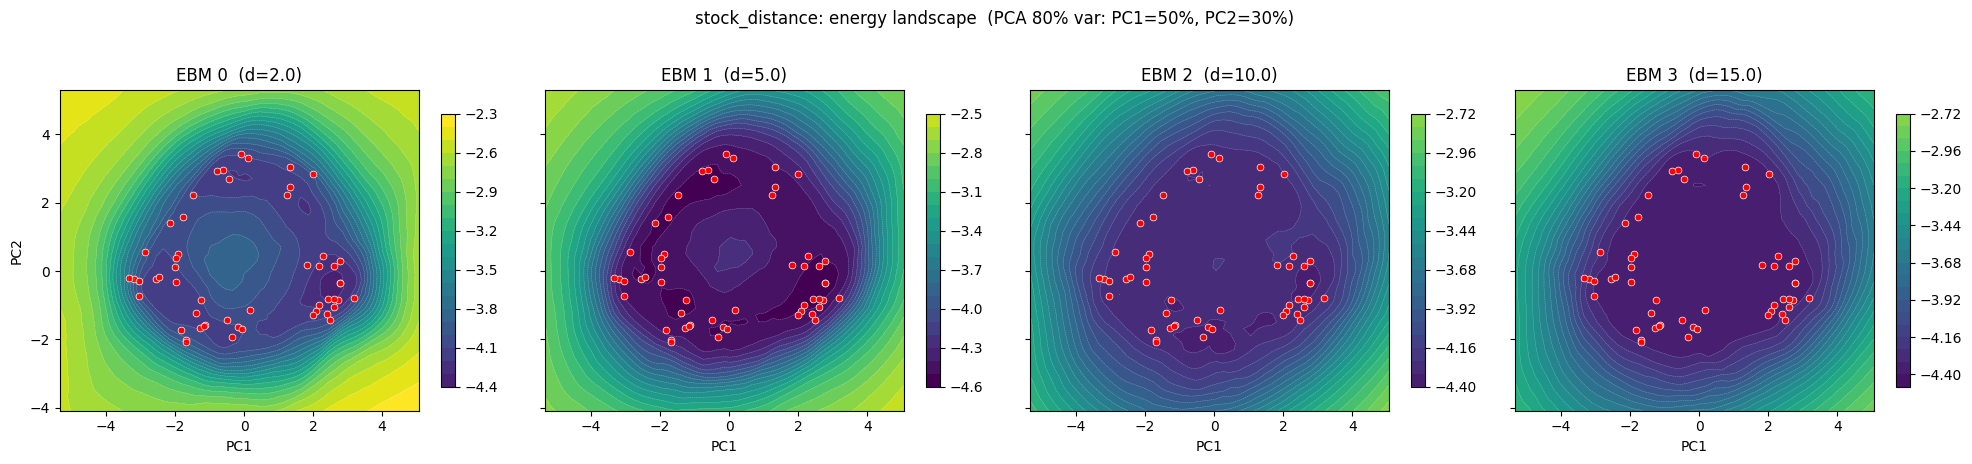

In [66]:
all_E_d, ZZ1_d, ZZ2_d, Zc_d, pca_d = plot_ebm_map('experiments/ebms/stock_distance', gpu=0)

### D.2 Subsample ensemble — 4 EBMs

[stock_subsample]  PCA variance: 79.9%  grid: (48, 53)  total points: 2544
  EBM 0 (d=5.0): E [-4.211, -2.547]
  EBM 1 (d=5.0): E [-4.387, -2.543]
  EBM 2 (d=5.0): E [-4.188, -2.629]
  EBM 3 (d=5.0): E [-4.305, -2.555]


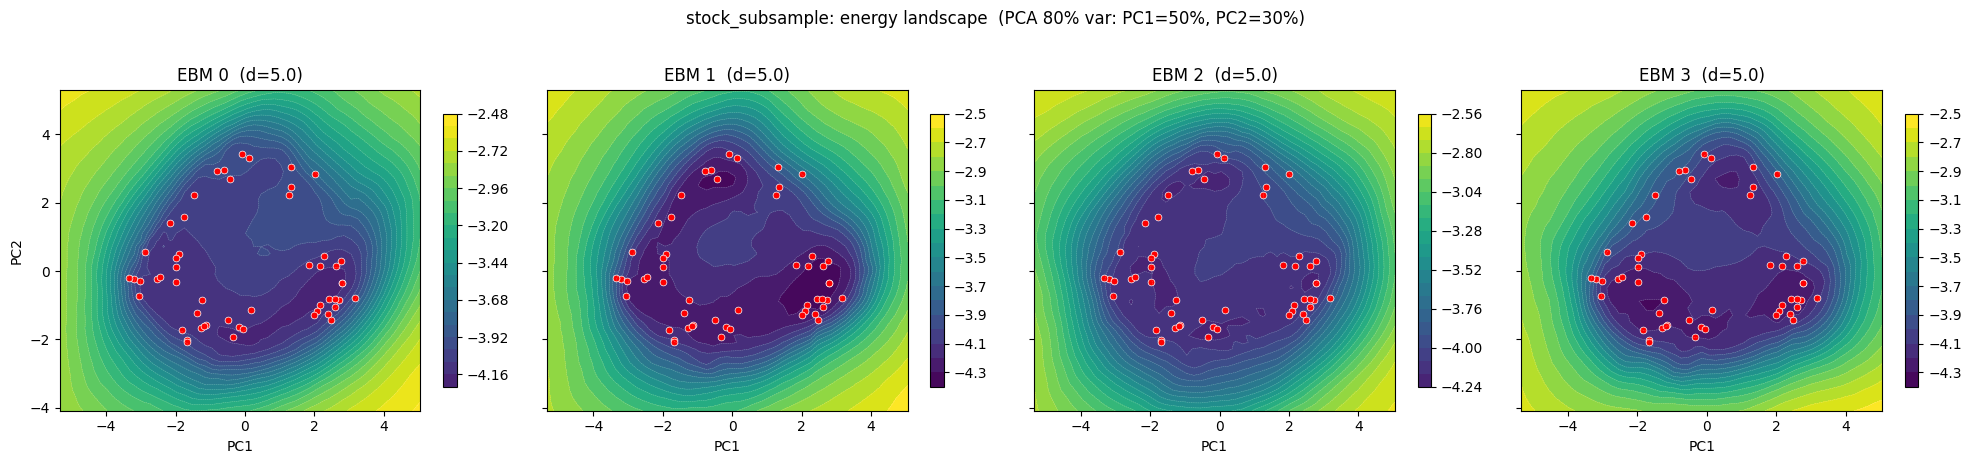

In [67]:
all_E_s, ZZ1_s, ZZ2_s, Zc_s, pca_s = plot_ebm_map('experiments/ebms/stock_subsample', gpu=0)

### D.3 Per-EBM energy 통계 (grid 전체 기준)

In [68]:
rows = []
for method_name, all_E, meta_path in [
    ('distance',  all_E_d, 'experiments/ebms/stock_distance/meta.json'),
    ('subsample', all_E_s, 'experiments/ebms/stock_subsample/meta.json'),
]:
    meta = json.loads(Path(meta_path).read_text())
    for i, E in enumerate(all_E):
        rows.append({
            'method': method_name,
            'ebm': i,
            'neg_distance': meta['neg_distances'][i],
            'E_min': float(E.min()),
            'E_max': float(E.max()),
            'E_mean': float(E.mean()),
            'E_std': float(E.std()),
        })
print(pd.DataFrame(rows).to_string(index=False))

   method  ebm  neg_distance   E_min   E_max  E_mean  E_std
 distance    0           2.0 -4.3398 -2.3574 -3.2878 0.6082
 distance    1           5.0 -4.5469 -2.5391 -3.7118 0.6231
 distance    2          10.0 -4.3516 -2.7656 -3.8686 0.4077
 distance    3          15.0 -4.4023 -2.7305 -3.8646 0.4588
subsample    0           5.0 -4.2109 -2.5469 -3.4632 0.4900
subsample    1           5.0 -4.3867 -2.5430 -3.4916 0.5385
subsample    2           5.0 -4.1875 -2.6289 -3.5227 0.4840
subsample    3           5.0 -4.3047 -2.5547 -3.4489 0.5245
